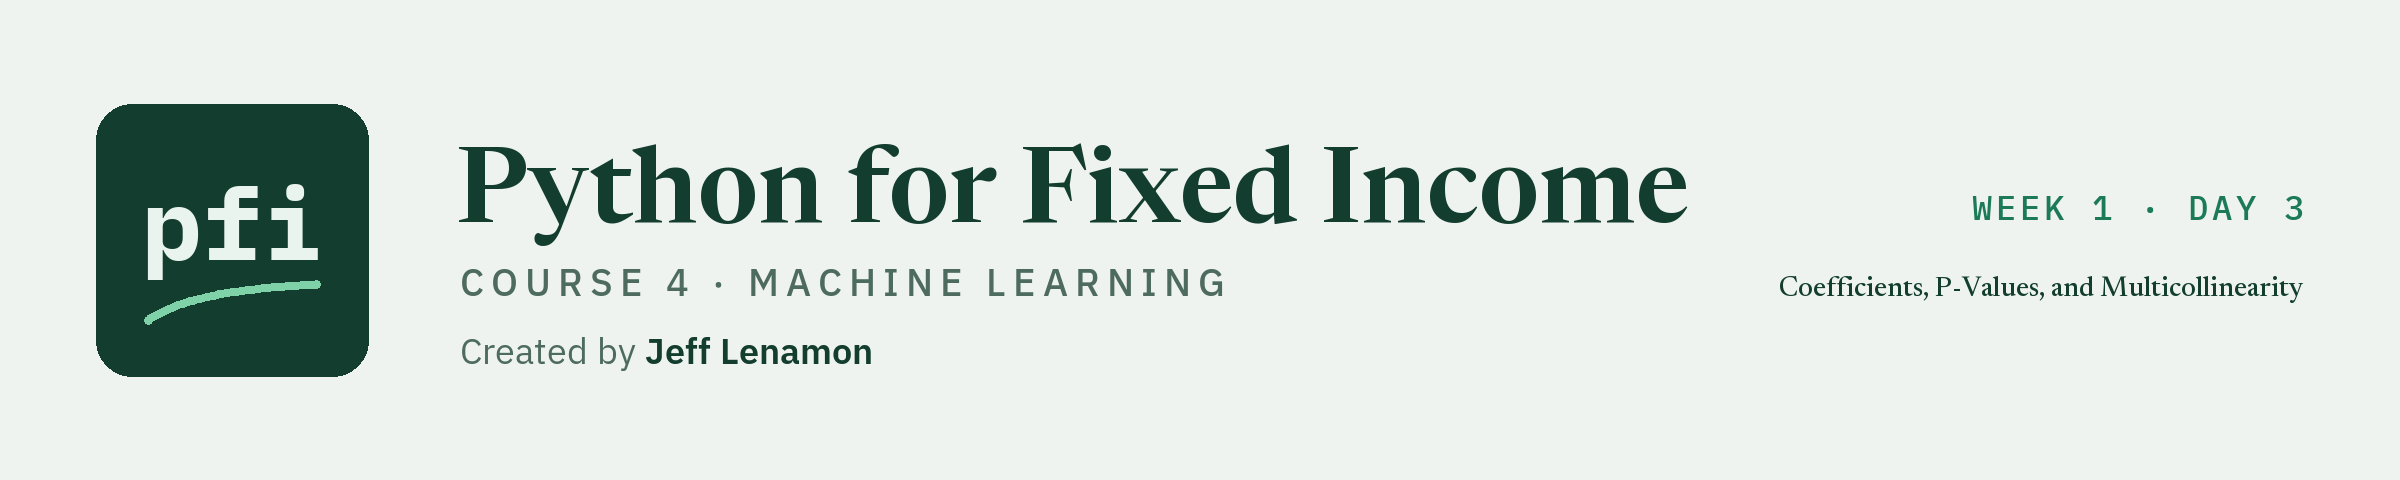

# Coefficients, P-Values, and Multicollinearity

Week 1, Day 3. A coefficient is a number fitted from a sample, so it comes with uncertainty. Today: standard errors, t, p-values, and intervals in statsmodels, what a p-value does and does not say, association against cause, and what overlapping features do to all of it.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week1/day3/03_coefficients_p_values_and_multicollinearity.ipynb)

Yesterday's model gave every feature a coefficient: a step for each rating, a slope for duration, a step for each sector. Every one of those numbers was fitted from the 615 training bonds of a file, and a different set of bonds would have given different numbers. Today asks how different: **how precisely is each coefficient pinned down, and which ones can the data tell apart from zero?**

That is what a regression table answers, and it is easy to read it wrong. A small p-value is read as "this feature matters", a large one as "this feature does nothing", and both readings go further than the number does. Today you read the table on a file where the answer is known, because the course wrote the recipe.

**The data is synthetic.** The 821 bonds of `benchmark.csv` belong to invented issuers, and their spreads were generated by the course's own script, `tools/make_holdings.py`, from each bond's rating, its years to maturity, an effect shared by each issuer's bonds, and random noise. **Sector plays no part in the recipe**, and **duration does not appear in it either**: the recipe uses years to maturity. Every coefficient and p-value today is an association in an invented dataset that partly recovers its own recipe, never a statement about how spreads behave in a market.

Today you will:

1. Fit the same model in statsmodels and scikit-learn and get the same coefficients, then read what statsmodels adds.
2. Read a coefficient table: coefficient, standard error, t, p-value, interval.
3. Look at sector, a feature the recipe never used, and test it jointly.
4. Say why a coefficient is an association and not a cause, with duration as the example.
5. Add years to maturity beside duration and watch the standard errors grow; measure the overlap with `vif_table`.
6. Meet perfect collinearity: `spread_duration` equals `duration`.
7. Drop a feature by VIF on the training rows, refit, and compare.
8. Say why bonds of one issuer are not independent, and what that does to the p-values.

Q. Set up today's work folder: the thread settings, the seed, today's three data files, and the module as it stood at the end of day 2.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_03_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_03_cwqtxh27, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies']


* `mlkit.py` holds days 1 and 2: `assert_disjoint`, `regression_metrics`, `adjusted_r2`, and `rating_dummies`. Today adds `vif_table`.

Q. Make the work folder a repository and commit the start-of-day files, so the Git section can show exactly what today adds.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_03_cwqtxh27 and nowhere else


Q. Tell Git which files never to track, as on day 1: the bytecode cache, pytest's cache, and Excel workbooks.

In [7]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [8]:
# the start of the day, committed before anything is added
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Start of day 3: mlkit as it stands after day 2"
!git -C "{work}" log --oneline

d577a3d Start of day 3: mlkit as it stands after day 2


* One commit: the module as it stood at the end of day 2, and `.gitignore`. Its hash changes on every run.

## 3.1 statsmodels OLS: The Same Coefficients, Plus Their Uncertainty

Q. Load the bonds, give each its rating score, and add the two columns today needs: `log_oas` and years to maturity.

The bonds are invented, and their spreads come from the course's generator, not from any market.

In [9]:
# the 821 synthetic benchmark bonds, with the rating score from ratings.csv
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
assert bench["score"].notna().all(), "a bond has a rating that ratings.csv does not list"

# today's target: the natural log of OAS in bp
bench["log_oas"] = np.log(bench["oas"])
# years from the file's date to maturity (days / 365.25); the generator counts them on a 30/360 basis, a close match
bench["years_to_maturity"] = (pd.to_datetime(bench["maturity"]) - pd.to_datetime(bench["as_of_date"])).dt.days / 365.25

print(f"{len(bench):,} bonds of {bench['ticker'].nunique()} invented issuers; OAS from {bench['oas'].min()} to {bench['oas'].max()} bp")

821 bonds of 150 invented issuers; OAS from 15 to 2074 bp


**Today's target is `log_oas`, the natural log of OAS in bp.** Day 4 shows why logs suit these spreads (the recipe multiplies its parts, so in logs they add) and checks the model's assumptions. Today you need one reading rule: a coefficient b on `log_oas` means that one more unit of the feature goes with a spread about **100 x (exp(b) - 1) percent** wider, other features fixed. For a small b that is close to 100 x b percent.

Q. Build the features: rating score, duration, and one dummy column per sector, with `Consumer` as the reference level.

In [10]:
# one float column per sector; Consumer is dropped by name, so it is the reference level the intercept stands for
sectors = pd.get_dummies(bench["sector"], prefix="sector", dtype=float).drop(columns="sector_Consumer")

X = pd.concat([bench[["score", "duration"]], sectors], axis=1)
y = bench["log_oas"]
print(f"{X.shape[1]} features: {list(X.columns)}")

11 features: ['score', 'duration', 'sector_Energy', 'sector_Financials', 'sector_Health Care', 'sector_Industrials', 'sector_Materials', 'sector_Technology', 'sector_Telecom', 'sector_Transportation', 'sector_Utilities']


* 11 features. `Consumer` is the reference because it is the first sector alphabetically, a choice stated here, as day 2 did. Each sector coefficient is then the difference from a `Consumer` bond, in `log_oas`, other features fixed.

Q. Make the course's split and prove no bond is on both sides.

In [11]:
from sklearn.model_selection import train_test_split

# the course split: a quarter of the bonds to the test set, the same bonds as on days 1 and 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
mlkit.assert_disjoint(X_train.index, X_test.index)
print(f"training rows: {len(X_train)}; test rows: {len(X_test)}; no bond in both")

training rows: 615; test rows: 206; no bond in both


* 615 training rows and 206 test rows. Everything in today's inference is fitted on the training rows only: the test rows are for the reported errors in section 3.7.

Q. Fit the model with statsmodels on the training rows.

In [12]:
import statsmodels.api as sm

# statsmodels fits exactly the columns it is given: add_constant adds the intercept column, named const
design_train = sm.add_constant(X_train)
fit = sm.OLS(y_train, design_train).fit()

print(f"rows: {int(fit.nobs)}; coefficients: {len(fit.params)} (an intercept and {len(fit.params) - 1} features); "
      f"residual degrees of freedom: {int(fit.df_resid)}")
print(f"R-squared on the training rows: {fit.rsquared:.4f}")

rows: 615; coefficients: 12 (an intercept and 11 features); residual degrees of freedom: 603
R-squared on the training rows: 0.8847


* 12 coefficients from 615 rows leave 603 **residual degrees of freedom** (615 - 11 - 1). They set how wide the t distribution behind each p-value is, and Excel reports the same number.

Q. Does scikit-learn's `LinearRegression` give the same coefficients?

In [13]:
from sklearn.linear_model import LinearRegression

# scikit-learn adds the intercept itself; statsmodels needed add_constant
linear = LinearRegression().fit(X_train, y_train)
same_intercept = abs(linear.intercept_ - fit.params["const"]) < 1e-9
same_slopes = np.allclose(linear.coef_, fit.params[X_train.columns], rtol=0, atol=1e-9)
print(f"same intercept within 1e-9: {same_intercept}; same {len(linear.coef_)} coefficients within 1e-9: {same_slopes}")

same intercept within 1e-9: True; same 11 coefficients within 1e-9: True


* The same least squares fit. scikit-learn stops at the coefficients, because its job is the model's output on new rows. statsmodels goes on to say **how uncertain** each coefficient is, which is what today is about. The course uses statsmodels for inference and scikit-learn for pipelines (day 5).

Q. What happens if the constant is left out?

In [14]:
# the same columns without add_constant: statsmodels then fits a model with no intercept at all
fit_no_constant = sm.OLS(y_train, X_train).fit()
print(f"score coefficient with the constant: {fit.params['score']:.4f}; without it: {fit_no_constant.params['score']:.4f}")
print(f"'const' among the coefficients without it: {'const' in fit_no_constant.params.index}")

score coefficient with the constant: 0.2016; without it: 0.3055
'const' among the coefficients without it: False


* 0.2016 against 0.3055: a different model, with the line forced through zero, and no error to say so. With statsmodels, `sm.add_constant` is part of every fit in this course.

## 3.2 Reading the Coefficient Table

Q. Print statsmodels' coefficient table.

`fit.summary()` prints three tables, and the first carries the date and time of the run, which would change every time the notebook runs. The coefficients are in the second table, `tables[1]`.

In [15]:
# the coefficient table of the summary: one row per coefficient
print(fit.summary().tables[1])

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.9102      0.051     56.784      0.000       2.810       3.011
score                     0.2016      0.003     67.108      0.000       0.196       0.208
duration                  0.0197      0.003      5.956      0.000       0.013       0.026
sector_Energy            -0.0126      0.048     -0.262      0.793      -0.107       0.082
sector_Financials         0.0371      0.048      0.772      0.440      -0.057       0.132
sector_Health Care       -0.0043      0.053     -0.082      0.935      -0.108       0.100
sector_Industrials       -0.0107      0.049     -0.221      0.825      -0.106       0.085
sector_Materials         -0.0200      0.046     -0.433      0.665      -0.111       0.071
sector_Technology         0.0538      0.056      0.958      0.339      -0.056       0.164
sector_Tel

Read one row, `duration`, column by column:

| Column | `duration` | Reads as |
| --- | --- | --- |
| `coef` | 0.0197 | One more year of duration goes with a `log_oas` 0.0197 higher, other features fixed: a spread about 2.0 percent wider, in this file |
| `std err` | 0.0033 | How much the coefficient would typically move from one sample of bonds to another, if the model's assumptions held |
| `t` | 5.96 | The coefficient divided by its standard error: how many standard errors it is from zero |
| `P>\|t\|` | 0.000 | The p-value, shown with 3 decimals: 0.000 means below 0.0005, not zero |
| `[0.025 0.975]` | 0.013 to 0.026 | The 95 percent interval: coefficient plus or minus about 2 standard errors |

Q. Build the course's own table: p-values with 3 significant figures, and each coefficient read as a percent.

In [16]:
def p_text(p):
    """A p-value as the course prints it: 3 significant figures, and below 0.001 as < 0.001."""
    return "< 0.001" if p < 0.001 else f"{p:.3g}"

interval = fit.conf_int(alpha=0.05)
coef_table = pd.DataFrame({
    "coef": fit.params,
    "std_err": fit.bse,
    "t": fit.tvalues,
    "p_value": fit.pvalues,
    "ci_low": interval[0],
    "ci_high": interval[1],
})
# 100 x (exp(b) - 1): the approximate percent change in the spread for one more unit of the feature
coef_table["percent_per_unit"] = 100 * (np.exp(coef_table["coef"]) - 1)
# the intercept is not a feature, so it has no percent reading
coef_table.loc["const", "percent_per_unit"] = np.nan

shown = coef_table.round({"coef": 4, "std_err": 4, "t": 2, "ci_low": 4, "ci_high": 4, "percent_per_unit": 1})
shown["p_value"] = coef_table["p_value"].map(p_text)
shown

,coef,std_err,t,p_value,ci_low,ci_high,percent_per_unit
const,2.9102,0.0512,56.78,< 0.001,2.8095,3.0108,NaN
score,0.2016,0.0030,67.11,< 0.001,0.1957,0.2075,22.3
duration,0.0197,0.0033,5.96,< 0.001,0.0132,0.0262,2.0
sector_Energy,-0.0126,0.0481,-0.26,0.793,-0.1071,0.0818,-1.3
sector_Financials,0.0371,0.0481,0.77,0.44,-0.0573,0.1316,3.8
sector_Health Care,-0.0043,0.0530,-0.08,0.935,-0.1083,0.0997,-0.4
sector_Industrials,-0.0107,0.0486,-0.22,0.825,-0.1062,0.0847,-1.1
sector_Materials,-0.0200,0.0462,-0.43,0.665,-0.1108,0.0707,-2.0
sector_Technology,0.0538,0.0561,0.96,0.339,-0.0565,0.1640,5.5
sector_Telecom,-0.0497,0.0463,-1.07,0.283,-0.1405,0.0411,-4.8


* **Score:** 0.2016 per notch, a spread about 22.3 percent wider per notch down the rating scale, with an interval of 0.1957 to 0.2075. The recipe multiplies the spread by a base that rises with every notch, and the coefficient recovers a step of that size.
* **Duration:** 0.0197 per year of duration, about 2.0 percent, interval 0.0132 to 0.0262. Section 3.4 asks what that number is really picking up.
* The **percent column is for features**, so the intercept's is left empty (NaN): the intercept is the `log_oas` of a `Consumer` bond with score 0 and duration 0, a bond that does not exist.

Q. Where does a p-value come from? Compute duration's t and p by hand.

In [17]:
from scipy import stats

# t: the coefficient over its standard error
t_duration = fit.params["duration"] / fit.bse["duration"]
# p: the chance of a t at least this far from zero, either side, in a t distribution with the residual degrees of freedom
p_duration = 2 * stats.t.sf(abs(t_duration), fit.df_resid)

print(f"t = {t_duration:.2f}; p {p_text(p_duration)}")
print(f"equal to statsmodels' p-value within 1e-12: {abs(p_duration - fit.pvalues['duration']) < 1e-12}")

t = 5.96; p < 0.001
equal to statsmodels' p-value within 1e-12: True


**What a p-value says, in plain words.** Suppose the true coefficient were zero and the model's assumptions held. Then samples like this one would still give coefficients scattered around zero, by chance. The p-value is the share of such samples that would give a t at least as far from zero as the one we got. Duration's t of 5.96 would almost never turn up by chance, so its p-value is tiny.

**What a p-value does not say.** It is **not** the probability that the coefficient is real, and not the probability that the feature matters. It is not a measure of size: a tiny effect can have a tiny p-value with enough rows. And it is not evidence of cause. The course calls a coefficient with p below 0.05 **distinguishable from zero at the 0.05 level**: 0.05 is a convention, not a law.

**The interval.** The 95 percent interval is the coefficient plus or minus `t.ppf(0.975, df)` standard errors (about 1.96 here). Read it as the range of values the data are consistent with, given the model's assumptions. Duration's runs from 1.3 to 2.6 percent per year: the sign is clear, the size is known only roughly.

## 3.3 Sector: A Feature the Generator Never Used

The recipe gives every bond a spread from its rating, its years to maturity, its issuer, and noise. **It never looks at sector.** So the true coefficient of every sector dummy is zero, and today you can see what the table shows for a feature whose answer is known.

Q. What p-values do the 9 sector dummies get?

In [18]:
sector_rows = coef_table.loc[[name for name in coef_table.index if name.startswith("sector_")], ["coef", "std_err", "p_value"]]
print(f"sector dummies with p below 0.05: {(sector_rows['p_value'] < 0.05).sum()} of {len(sector_rows)}")
print(f"smallest p: {p_text(sector_rows['p_value'].min())} ({sector_rows['p_value'].idxmin()}); "
      f"largest: {p_text(sector_rows['p_value'].max())}")
sector_rows.assign(p_value=sector_rows["p_value"].map(p_text)).round(4)

sector dummies with p below 0.05: 0 of 9
smallest p: 0.283 (sector_Telecom); largest: 0.935


,coef,std_err,p_value
sector_Energy,-0.0126,0.0481,0.793
sector_Financials,0.0371,0.0481,0.44
sector_Health Care,-0.0043,0.0530,0.935
sector_Industrials,-0.0107,0.0486,0.825
sector_Materials,-0.0200,0.0462,0.665
sector_Technology,0.0538,0.0561,0.339
sector_Telecom,-0.0497,0.0463,0.283
sector_Transportation,-0.0347,0.0478,0.468
sector_Utilities,0.0146,0.0471,0.757


* None of the 9 is below 0.05; the smallest p-value is 0.283 (Telecom) and the largest 0.935. The data cannot tell any sector apart from `Consumer`.
* Every sector coefficient is a few hundredths in `log_oas`, either side of zero, with a standard error about as large. That is what noise looks like in a coefficient table.
* **A large p-value does not prove a coefficient is zero.** It says the data are consistent with zero, and with other values too: `sector_Technology`'s interval runs from -5.5 to 17.8 percent. Here we know the truth is zero because we wrote the recipe. On real data nobody hands you the recipe.

Q. Test all nine together: can the data tell the sector dummies, as a group, apart from zero?

With nine separate tests at 0.05, the chance that at least one comes in below 0.05 by luck alone is about 37%, if the tests were independent. The **F-test** asks one question about the group instead.

In [19]:
# one row per sector coefficient: each row says "this coefficient = 0"
names = list(fit.params.index)
restriction = np.zeros((len(sector_rows), len(names)))
for row, name in enumerate(sector_rows.index):
    restriction[row, names.index(name)] = 1.0

joint = fit.f_test(restriction)
print(f"F = {float(np.squeeze(joint.fvalue)):.2f} on {len(sector_rows)} and {int(fit.df_resid)} degrees of freedom; p {p_text(float(joint.pvalue))}")

F = 0.82 on 9 and 603 degrees of freedom; p 0.599


* F = 0.82, p = 0.599. As a group, the sector dummies add nothing the data can tell apart from noise. The course's recipe agrees, because it has no sector term.
* `f_test` takes a matrix with one row per restriction. The shorter text form, `f_test("sector_Energy = 0, ...")`, breaks on a name with a space in it, such as `sector_Health Care`.

Q. What does "p below 0.05" mean for a feature that has no effect at all? Add a column of pure noise to the model 1,000 times and count.

noise columns with p below 0.05: 59 of 1,000; below 0.01: 12


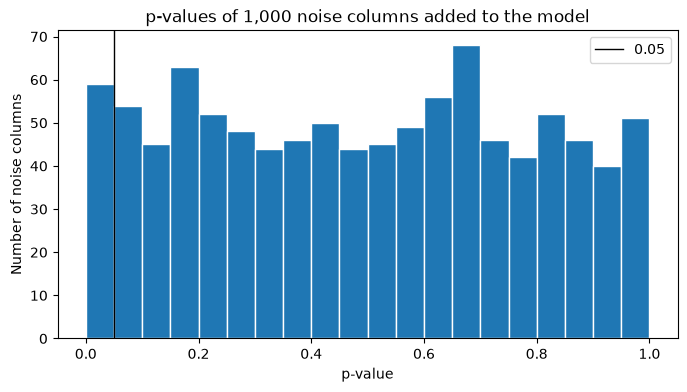

In [20]:
import matplotlib.pyplot as plt

# a seeded generator, so every run draws the same 1,000 noise columns
rng = np.random.default_rng(SEED)
noise_p_values = []
for draw in range(1000):
    # a column of random numbers: by construction it has nothing to do with the spreads
    noise = rng.normal(size=len(X_train))
    fit_noise = sm.OLS(y_train, design_train.assign(noise=noise)).fit()
    noise_p_values.append(fit_noise.pvalues["noise"])
noise_p_values = np.array(noise_p_values)

print(f"noise columns with p below 0.05: {(noise_p_values < 0.05).sum()} of 1,000; below 0.01: {(noise_p_values < 0.01).sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(noise_p_values, bins=20, range=(0, 1), edgecolor="white")
ax.axvline(0.05, color="black", linewidth=1, label="0.05")
ax.set_title("p-values of 1,000 noise columns added to the model")
ax.set_xlabel("p-value")
ax.set_ylabel("Number of noise columns")
ax.legend()
plt.show()

* 59 of 1,000 noise columns came in below 0.05, about the 5 percent the level allows, and 12 below 0.01. The p-values of a feature with no effect spread evenly from 0 to 1.
* That is what the 0.05 level means: **if a feature had no effect, it would still come in below 0.05 about one time in twenty.** Fit enough features and some will, by chance alone. A list of features "significant at 0.05" chosen from many is not a finding until it holds on rows that were not used to choose it.

## 3.4 Association Is Not Cause, in Desk Terms

The course reads every coefficient with one sentence: **"Holding the other features fixed, a one-unit difference in x goes with a b difference in the fitted y, in this data."** Not "causes", not "drives", not "explains why".

Duration shows why the sentence is worded that way. Its coefficient is 0.0197, with p < 0.001. But the recipe never uses duration. It uses years to maturity, capped at 10.

Q. How closely does duration move with years to maturity on the training rows?

correlation of duration and years to maturity on the 615 training rows: 0.9457


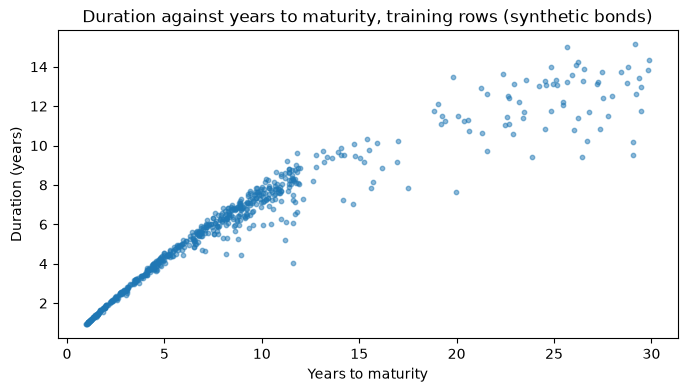

In [21]:
train_bonds = bench.loc[X_train.index]
corr = train_bonds["duration"].corr(train_bonds["years_to_maturity"])
print(f"correlation of duration and years to maturity on the {len(train_bonds)} training rows: {corr:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(train_bonds["years_to_maturity"], train_bonds["duration"], s=10, alpha=0.5)
ax.set_title("Duration against years to maturity, training rows (synthetic bonds)")
ax.set_xlabel("Years to maturity")
ax.set_ylabel("Duration (years)")
plt.show()

* A correlation of 0.9457: duration rises with maturity, and bends as it goes, because a long bond's later cash flows count less. Duration's coefficient is real arithmetic on real rows, and it picks up the effect of the column the recipe used, which the model was not given.
* In desk terms: "bonds with longer duration have wider spreads in this file" is a fair description. "Longer duration widens the spread" is a claim about cause, and the recipe shows it is false here: change a bond's duration without changing its maturity, and the recipe's spread does not move.
* On real bonds nobody hands you the recipe. A coefficient can stand in for a feature you left out, for a feature measured with error, or for the way the bonds were chosen. The coefficient table cannot tell you which. That takes knowledge of how the data came about.

## 3.5 Multicollinearity: Duration Against Years to Maturity

If years to maturity is the column the recipe used, why not give the model both? Because the two move so closely together that the data cannot share the effect out between them.

Q. Add years to maturity beside duration and refit on the training rows.

In [22]:
# the same features plus years to maturity, on the same rows
X_train_years = pd.concat([X_train, bench.loc[X_train.index, ["years_to_maturity"]]], axis=1)
X_test_years = pd.concat([X_test, bench.loc[X_test.index, ["years_to_maturity"]]], axis=1)
fit_years = sm.OLS(y_train, sm.add_constant(X_train_years)).fit()

for name in ["duration", "years_to_maturity"]:
    print(f"{name:18} coef {fit_years.params[name]:.4f}  std err {fit_years.bse[name]:.4f}  p {p_text(fit_years.pvalues[name])}")
print(f"duration alone (section 3.2): coef {fit.params['duration']:.4f}  std err {fit.bse['duration']:.4f}  p {p_text(fit.pvalues['duration'])}")

duration           coef 0.0067  std err 0.0111  p 0.545
years_to_maturity  coef 0.0064  std err 0.0052  p 0.22
duration alone (section 3.2): coef 0.0197  std err 0.0033  p < 0.001


* With both in the model, **neither is distinguishable from zero**: duration's p-value is 0.545 and years to maturity's 0.22. Duration's standard error grew from 0.0033 to 0.0111, 3.4 times as large.
* Read too fast, the table says "maturity does not matter". It does: the recipe is built on it.

Q. Test the two together.

In [23]:
# two restrictions: duration = 0 and years_to_maturity = 0
names_years = list(fit_years.params.index)
restriction_years = np.zeros((2, len(names_years)))
restriction_years[0, names_years.index("duration")] = 1.0
restriction_years[1, names_years.index("years_to_maturity")] = 1.0
joint_years = fit_years.f_test(restriction_years)
print(f"duration and years to maturity together: F = {float(np.squeeze(joint_years.fvalue)):.2f}, p {p_text(float(joint_years.pvalue))}")

duration and years to maturity together: F = 18.50, p < 0.001


* F = 18.50, p < 0.001. Together the two are plainly distinguishable from zero; separately, neither is. The data know that something maturity-like goes with wider spreads. They cannot say how much belongs to duration and how much to years, because the two rarely move apart. That is **multicollinearity**: the fit is fine, and the individual coefficients are poorly pinned down.

The usual measure is the **variance inflation factor**. Regress one feature on all the others; if that regression's R-squared is R2_j, the feature's VIF is 1 / (1 - R2_j). A VIF of 1 means no overlap; the course calls above 5 high and above 10 very high, as conventions. The VIF is the factor by which the overlap multiplies the variance of that coefficient, so the standard error grows by about its square root.

Q. Add `vif_table` to `mlkit.py`, docstring first.

In [24]:
%%writefile -a mlkit.py


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)

Appending to mlkit.py


* The function regresses each column on a constant and the others with `np.linalg.lstsq`, so it needs nothing beyond numpy, and it returns infinity when a column is an exact combination of others (section 3.6).
* It **raises** on fewer than two columns, or too few rows to fit.

Q. Add three tests: agreement with statsmodels' own `variance_inflation_factor`, agreement with Excel, and the perfect-collinearity case.

In [25]:
%%writefile -a test_mlkit.py


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5

Appending to test_mlkit.py


* `m3_features` builds today's features (score, duration, the nine sector dummies) the way the notebook does, from `read_bench` and day 2's `sector_dummies`.
* The Excel test reads every VIF from the course's Excel reference file, computed over all 821 bonds with `=1/(1-INDEX(LINEST(...),3,1))`.

Q. Reload the module and run the tests.

In [26]:
# the file changed, so reload before using the new function
importlib.reload(mlkit)
print(f"vif_table in mlkit: {hasattr(mlkit, 'vif_table')}")

vif_table in mlkit: True


In [27]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.............                                                            [100%]
13 passed in 1.80s



* `13 passed`: the 10 from days 1 and 2 and today's three.

Q. What are the VIFs, with and without years to maturity? Compute them on the training rows.

In [28]:
vif_compare = pd.DataFrame({
    "without years": mlkit.vif_table(X_train),
    "with years": mlkit.vif_table(X_train_years),
}).sort_values("with years", ascending=False)
vif_compare.round(2).head(5)

,without years,with years
duration,1.03,11.56
years_to_maturity,NaN,11.35
sector_Telecom,2.13,2.14
sector_Materials,2.13,2.13
sector_Utilities,2.08,2.09


* Without years to maturity every VIF is low: duration's is 1.03 and the highest is 2.13 (sector_Telecom). The sector dummies sit near 2 because a bond belongs to exactly one sector, so the dummies overlap a little with each other: normal for a set of dummies.
* With it, duration's VIF is 11.56 and years to maturity's 11.35: both very high.

Q. Does the standard error grow by about the square root of the VIF?

In [29]:
se_ratio = fit_years.bse["duration"] / fit.bse["duration"]
vif_ratio = mlkit.vif_table(X_train_years)["duration"] / mlkit.vif_table(X_train)["duration"]
print(f"duration's standard error grew {se_ratio:.2f} times; the square root of its VIF ratio is {np.sqrt(vif_ratio):.2f}")

duration's standard error grew 3.35 times; the square root of its VIF ratio is 3.35


* 3.35 against 3.35: close, not equal, because adding a feature also changes the residual variance a little. The VIF tells you in advance how much less precise a coefficient will be.

## 3.6 Perfect Collinearity: spread_duration Equals duration

Q. The file has a `spread_duration` column. How does it compare with `duration`?

In [30]:
same = (bench["spread_duration"] == bench["duration"]).sum()
print(f"spread_duration equals duration on {same} of {len(bench)} bonds")

spread_duration equals duration on 821 of 821 bonds


* On every bond: the generator sets spread duration equal to duration. A copy of a column adds nothing, and it breaks the arithmetic: the regression of `duration` on the other features fits perfectly, R2_j is 1, and the VIF is 1 / 0.

Q. What does `vif_table` give for score, duration, and spread duration?

In [31]:
vif_copy = mlkit.vif_table(bench.loc[X_train.index, ["score", "duration", "spread_duration"]])
# the copies' VIF is infinite, or a huge number if the last digit of R-squared rounds just below 1
print(f"duration and spread_duration: above 1e10 or infinite: {bool((vif_copy[['duration', 'spread_duration']] > 1e10).all())}")
print(f"score: {vif_copy['score']:.2f}")

duration and spread_duration: above 1e10 or infinite: True
score: 1.01


* The two copies are infinite or astronomically high; score, which overlaps with neither, is 1.01. The cell prints a comparison, not the number itself, because whether R2_j comes out as exactly 1 or one rounding step below depends on the order the arithmetic was done in.

Q. What does statsmodels do with the copy in the model?

In [32]:
import warnings

# statsmodels warns when the columns are an exact combination of each other: record the warning and print it
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    fit_copy = sm.OLS(y_train, sm.add_constant(bench.loc[X_train.index, ["score", "duration", "spread_duration"]])).fit()
print(f"{caught[0].category.__name__}: {caught[0].message}")

fit_two = sm.OLS(y_train, sm.add_constant(bench.loc[X_train.index, ["score", "duration"]])).fit()
print(f"duration {fit_copy.params['duration']:.4f} + spread_duration {fit_copy.params['spread_duration']:.4f} "
      f"= {fit_copy.params['duration'] + fit_copy.params['spread_duration']:.4f}; duration alone: {fit_two.params['duration']:.4f}")

duration 0.0100 + spread_duration 0.0100 = 0.0201; duration alone: 0.0201


* A warning, and then an answer anyway: statsmodels splits duration's coefficient exactly in half, 0.0100 each, which add up to the 0.0201 of a model with duration alone. Any other split, 0 and 0.0201, or 1 and -0.9799, fits exactly as well. The data cannot choose, so the library picks one by a rule.
* Excel's `LINEST` picks differently: it sets one copy's coefficient and standard error to 0 (the Excel section below). Different software, different arbitrary answer, the same fitted values.
* The fix is to notice the copy and drop it. A VIF of infinity is the clearest sign there is.

## 3.7 Dropping a Feature by VIF, Refitting, and Comparing

A common rule: drop the feature with the highest VIF, refit, and repeat until every VIF is below a cut-off. Dropping a column is a modelling choice, so **the VIFs that make the choice are computed on the training rows only**, like everything else fitted to the data.

Q. Which feature has the highest VIF on the training rows, with years to maturity in? Drop it and refit.

In [33]:
# the choice is made from the training rows only
vif_years = mlkit.vif_table(X_train_years)
dropped = vif_years.index[0]
print(f"highest VIF: {dropped} ({vif_years.iloc[0]:.2f}); next: {vif_years.index[1]} ({vif_years.iloc[1]:.2f})")

X_train_drop, X_test_drop = X_train_years.drop(columns=dropped), X_test_years.drop(columns=dropped)
fit_drop = sm.OLS(y_train, sm.add_constant(X_train_drop)).fit()
print(f"after dropping {dropped}: highest VIF {mlkit.vif_table(X_train_drop).iloc[0]:.2f}; years to maturity coef "
      f"{fit_drop.params['years_to_maturity']:.4f}, std err {fit_drop.bse['years_to_maturity']:.4f}, p {p_text(fit_drop.pvalues['years_to_maturity'])}")

highest VIF: duration (11.56); next: years_to_maturity (11.35)
after dropping duration: highest VIF 2.13; years to maturity coef 0.0094, std err 0.0016, p < 0.001


* The rule drops **duration**, by a VIF margin of 0.20, and keeps years to maturity, the column the recipe used. That is luck: on another split the margin could go the other way. The VIF measures overlap; it cannot say which of two overlapping columns is the right one.
* After the drop the highest VIF is 2.13, and years to maturity is pinned down: 0.0094 per year (about 0.94 percent), standard error 0.0016.

Q. Do the three models differ on the test rows?

The test rows are used here for the reported errors. The fitted `log_oas` goes back to bp with `exp`; day 4 says exactly what that bp number is.

In [34]:
def test_errors(model_fit, X_rows):
    """Test R-squared on log_oas, and MAE and RMSE in bp after exp."""
    fitted_log = model_fit.predict(sm.add_constant(X_rows, has_constant="add"))
    log_metrics = mlkit.regression_metrics(y_test, fitted_log)
    bp_metrics = mlkit.regression_metrics(np.exp(y_test), np.exp(fitted_log))
    return {"test_r2": log_metrics["r2"], "test_mae_bp": bp_metrics["mae"], "test_rmse_bp": bp_metrics["rmse"]}

comparison = pd.DataFrame({
    "duration": test_errors(fit, X_test),
    "duration and years": test_errors(fit_years, X_test_years),
    f"{dropped} dropped": test_errors(fit_drop, X_test_drop),
}).T
comparison.round({"test_r2": 4, "test_mae_bp": 1, "test_rmse_bp": 1})

,test_r2,test_mae_bp,test_rmse_bp
duration,0.8690,35.9,85.6
duration and years,0.8690,35.2,84.0
duration dropped,0.8684,34.9,83.3


* Test MAE of 35.9, 35.2, and 34.9 bp; test R-squared 0.8690, 0.8690, 0.8684. The three models fit the test rows almost equally well.
* So multicollinearity is a problem for **reading coefficients**, not for the fitted values. If all you need is the model's spread for a bond with these characteristics, two overlapping columns do little harm. If you want to say what each column goes with, they do a lot.

## 3.8 Bonds of One Issuer Are Not Independent

Every standard error and p-value today rests on assumptions, and one of them is that each bond's error is independent of every other bond's. The recipe breaks it on purpose: all the bonds of one issuer share one issuer effect.

Q. Do the bonds of one issuer share their rating and sector?

In [35]:
# the most distinct ratings and sectors any one issuer has
print(bench.groupby("ticker")[["rating", "sector"]].nunique().max().to_string())

rating    1
sector    1


* Every issuer's bonds share one rating and one sector. So the 615 training bonds carry only 149 issuers' worth of information about rating and sector.

Q. How much of the residual variation is shared within an issuer? Compare with the same calculation on issuer labels shuffled at random.

In [36]:
residuals = fit.resid
issuer = bench.loc[X_train.index, "ticker"]

def shared_share(labels):
    """The share of the residuals' sum of squares that is the residuals' mean within each label."""
    means = residuals.groupby(labels).transform("mean")
    return (means ** 2).sum() / (residuals ** 2).sum()

# 200 shufflings of the issuer labels: what the share looks like when bonds of one issuer have nothing in common
rng_shuffle = np.random.default_rng(SEED)
shuffled = [shared_share(pd.Series(rng_shuffle.permutation(issuer.to_numpy()), index=issuer.index)) for _ in range(200)]

print(f"real issuers: {shared_share(issuer):.1%} of the residual sum of squares is shared within an issuer")
print(f"shuffled labels: {np.mean(shuffled):.1%} on average, {np.max(shuffled):.1%} at most in 200 shufflings")

real issuers: 46.0% of the residual sum of squares is shared within an issuer
shuffled labels: 24.2% on average, 32.0% at most in 200 shufflings


* 46.0% with the real issuers, against 24.2% on average and at most 32.0% with shuffled labels. The residuals of one issuer's bonds move together: the issuer effect the model was not given.
* **What that does to the standard errors, in words.** OLS treats the 615 bonds as 615 independent pieces of information. For rating and sector, which never vary inside an issuer, there are really about 149. The usual standard errors are then too small, and the p-values too small with them: the coefficients are less precisely known than the table says. The coefficients themselves are not biased by this; their precision is overstated.
* The standard fix is **cluster-robust standard errors**, which let the errors of one issuer's bonds move together. They are a later topic. Day 5 shows the same problem from the other side, splitting the rows by issuer.

## Excel Side by Side

Excel's `LINEST` with its fourth argument `TRUE` returns the full set of statistics, and every coefficient, standard error, p-value, and interval above can be rebuilt from it. Excel has no function that splits rows, so the split is made in Python and the 615 training bonds are pasted on a sheet named `train`, headers in row 1: A `oas` (bp), B `log_oas` typed as `=LN(A2)` and filled down, C score, D duration, E to M the nine sector dummies (Energy to Utilities; Consumer is the reference), N years to maturity, O spread duration. Every formula below was typed into Excel by script on those rows (Excel 16.0 build 20430, 2026-10-04).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Coefficients, standard errors, R-squared, F, degrees of freedom | `sm.OLS(...).fit()` | `=LINEST(B2:B616,C2:M616,TRUE,TRUE)` in Q2, spilling 5 rows by 12 columns | duration 0.0197, standard error 0.0033, R-squared 0.8847, df 603 |
| p-value under each column | `fit.pvalues` | `=T.DIST.2T(ABS(Q2/Q3),$R$5)` in Q9, filled right | duration < 0.001, Telecom 0.283 |
| 95 percent interval | `fit.conf_int()` | `=Q2-T.INV.2T(0.05,$R$5)*Q3` and `=Q2+T.INV.2T(0.05,$R$5)*Q3` | duration 0.0132 to 0.0262 |
| VIF of duration | `vif_table(X_train)["duration"]` | `=1/(1-INDEX(LINEST(D2:D616,HSTACK(C2:C616,E2:M616),TRUE,TRUE),3,1))` | 1.03 |
| VIF of duration with years in | `vif_table(X_train_years)` | `=1/(1-INDEX(LINEST(D2:D616,HSTACK(C2:C616,E2:N616),TRUE,TRUE),3,1))` | 11.56 |
| Joint F-test of the sector dummies | `fit.f_test(...)` | `=((INDEX(LINEST(B2:B616,C2:D616,TRUE,TRUE),5,2)-$R$6)/9)/($R$6/$R$5)`, then `=F.DIST.RT(Q19,9,$R$5)` | F 0.82, p 0.599 |
| An exact copy in the columns | statsmodels splits the coefficient | `=LINEST(B2:B616,HSTACK(C2:D616,O2:O616),TRUE,TRUE)` | duration 0 with standard error 0; spread_duration 0.0201 |

**`LINEST` returns the columns in reverse.** The first column of its output is the last X column (Utilities) and the last is the intercept. Row 1 holds the coefficients, row 2 their standard errors, row 3 the R-squared and the standard error of y, row 4 the F statistic and the residual degrees of freedom (603, in R5), row 5 the regression and residual sums of squares (the residual one in R6). Reversed, the columns line up with statsmodels' order.

**The p-value.** `T.DIST.2T(ABS(Q2/Q3),$R$5)` is the coefficient over its standard error, made positive, then the two-tailed t probability with the residual degrees of freedom: the same calculation as `2 * stats.t.sf(...)` in section 3.2. `T.INV.2T(0.05,$R$5)` is the t value that leaves 5 percent in the two tails together, about 1.96 here, so the interval is the coefficient plus or minus that many standard errors.

**The VIF.** `HSTACK` (in this Excel) joins the score column and the sector columns into one block of "other columns", `LINEST` regresses duration on them, `INDEX(...,3,1)` picks the R-squared from row 3, column 1, and `1/(1-...)` turns it into the VIF. The Excel check computed every column's VIF the same way, with `CHOOSECOLS` picking the columns.

**The F-test.** The residual sum of squares of a fit without the sector dummies, `INDEX(LINEST(B2:B616,C2:D616,TRUE,TRUE),5,2)`, minus the full fit's (R6), divided by 9 restrictions, over the full fit's residual sum of squares per degree of freedom: `F.DIST.RT` turns F into its p-value.

**The copy.** With `spread_duration` beside `duration`, `LINEST` did not fail: it gave `duration` a coefficient of 0 and a standard error of 0, gave `spread_duration` the whole coefficient of a fit on score and duration alone, and counted the residual degrees of freedom as 612, as if the copy were not there. A 0 with a standard error of 0 in `LINEST` output is the sign of a column it set aside.

The **Analysis ToolPak** (Data, Data Analysis, Regression) is Excel's menu route to a regression table. This course shows `LINEST`, whose numbers were tested here.

In [37]:
# Excel's numbers on the training rows, from the day's Excel check, beside statsmodels' for four of the coefficients
excel_values = {
    "coef": {"const": 2.9101559977321383, "score": 0.2016487540288499, "duration": 0.019666102876496644, "sector_Telecom": -0.049699761364520555},
    "std_err": {"const": 0.05124932545558813, "score": 0.0030048275687393293, "duration": 0.003301870467763588, "sector_Telecom": 0.04625955194577196},
    "p_value": {"const": 3.6897157608863445e-244, "score": 6.379617881876023e-282, "duration": 4.391882098192039e-09, "sector_Telecom": 0.2830876974563324},
    "ci_low": {"const": 2.809507146458324, "score": 0.1957475555178259, "duration": 0.013181540071405137, "sector_Telecom": -0.14054916713510124},
    "ci_high": {"const": 3.0108048490059525, "score": 0.2075499525398739, "duration": 0.02615066568158815, "sector_Telecom": 0.041149644406060136},
}
excel_table = pd.DataFrame(excel_values)
python_table = coef_table.loc[excel_table.index, excel_table.columns]
print(f"every value within 1e-9: {bool(((excel_table - python_table).abs() < 1e-9).all().all())}")
excel_vif_duration = 1.027560734180684
print(f"VIF of duration within 1e-9: {abs(excel_vif_duration - mlkit.vif_table(X_train)['duration']) < 1e-9}")
excel_table.assign(p_value=excel_table["p_value"].map(p_text)).round(4)

every value within 1e-9: True
VIF of duration within 1e-9: True


,coef,std_err,p_value,ci_low,ci_high
const,2.9102,0.0512,< 0.001,2.8095,3.0108
score,0.2016,0.0030,< 0.001,0.1957,0.2075
duration,0.0197,0.0033,< 0.001,0.0132,0.0262
sector_Telecom,-0.0497,0.0463,0.283,-0.1405,0.0411


* Every value matches, and so did all twelve coefficients in the Excel check, with the F-test and every VIF.

Q. Add the last test of the day: statsmodels against scikit-learn on all 821 bonds, and both against Excel's `LINEST` and `T.DIST.2T` in the course's reference file.

In [38]:
%%writefile -a test_mlkit.py


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name

Appending to test_mlkit.py


* The reference file's regressions use all 821 bonds, not a split, so the test does not depend on which bonds a split picks.

In [39]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..............                                                           [100%]
14 passed in 1.88s



* `14 passed`.

## Save the Day with Git

Today's Git step reads exactly what a commit changed in one file: `git log -p -1 -- mlkit.py`. `-p` shows each commit's changes line by line, `-1` stops after one commit, and `-- mlkit.py` keeps only commits that touched `mlkit.py`.

Q. What has changed since the start-of-day commit?

In [40]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M mlkit.py
 M test_mlkit.py
?? benchmark.csv
?? course4_excel_reference.csv
?? ratings.csv


 mlkit.py      | 34 ++++++++++++++++++++++++++++++++++
 test_mlkit.py | 51 +++++++++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 85 insertions(+)


* `M` marks a modified file. The data files are copies and stay untracked.

Q. Commit today's work.

In [41]:
!git -C "{work}" add mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Add vif_table, with four tests: VIF, perfect collinearity, OLS against scikit-learn and Excel"
!git -C "{work}" log --oneline

47f8dfd Add vif_table, with four tests: VIF, perfect collinearity, OLS against scikit-learn and Excel
d577a3d Start of day 3: mlkit as it stands after day 2


Q. Add today's three models to the experiment log, `results.csv`, and commit it.

In [42]:
# one row per model: the day's three log_oas models; test_r2 on log_oas, MAE and RMSE in bp after exp
feature_lists = {
    "log_oas_score_duration_sector": "score, duration, sector",
    "log_oas_plus_years": "score, duration, sector, years_to_maturity",
    "log_oas_vif_dropped": "score, sector, years_to_maturity",
}
results = pd.DataFrame([
    {"model": model, "features": features, "train_rows": len(X_train), "test_rows": len(X_test), **errors}
    for (model, features), errors in zip(feature_lists.items(), comparison.to_dict(orient="records"))
])
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
log_oas_score_duration_sector,"score, duration, sector",615,206,0.8690,35.8858,85.5966
log_oas_plus_years,"score, duration, sector, years_to_maturity",615,206,0.8690,35.1981,84.0199
log_oas_vif_dropped,"score, sector, years_to_maturity",615,206,0.8684,34.8676,83.3292



In [43]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: three log_oas models, with duration, with years to maturity added, and duration dropped"
!git -C "{work}" log --oneline

b2f446c Experiment log: three log_oas models, with duration, with years to maturity added, and duration dropped
47f8dfd Add vif_table, with four tests: VIF, perfect collinearity, OLS against scikit-learn and Excel
d577a3d Start of day 3: mlkit as it stands after day 2


* Three commits: the start of the day, today's code, and its results. `test_r2` here is on `log_oas`, so it does not compare with day 1's R-squared in bp; the MAE in bp does.

Q. Read exactly what today added to `mlkit.py`.

In [44]:
# the latest commit that touched mlkit.py, with its changes line by line
!git -C "{work}" log -p -1 -- mlkit.py

commit 47f8dfd35e4b9a731f4aa51034433a34c1dee115
Author: Course Student <student@example.com>
Date:   Sun Oct 4 22:37:10 2026 -0400

    Add vif_table, with four tests: VIF, perfect collinearity, OLS against scikit-learn and Excel

diff --git a/mlkit.py b/mlkit.py
index d63047b..4723199 100644
--- a/mlkit.py
+++ b/mlkit.py
@@ -116,3 +116,37 @@ def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.
     # one column per level, 1.0 where the bond has that rating
     columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
     return pd.DataFrame(columns, index=ratings.index)
+
+
+def vif_table(X: pd.DataFrame) -> pd.Series:
+    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
+    the other features.
+
+    Input: X, the features as numeric columns (no constant column; one is added inside).
+    Output: a Series named vif, one value per column, sorted 

* The last commit is the experiment log, but `-- mlkit.py` skips it and shows the commit that changed the module: its message, then every added line with a `+` in front. That is the whole of today's change to the module, ready to review before it goes into your own folder.

## Bring It Home

Add today's function and tests to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code, with the course's `.venv` active.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste the code of the `%%writefile -a mlkit.py` cell (section 3.5), without its first line, at the end of `mlkit.py`. Paste the two `%%writefile -a test_mlkit.py` cells (section 3.5 and the Excel section), without their first lines, at the end of `test_mlkit.py`, in that order. Save both.

**Step 3.** Run the tests. Today's tests read no new data file.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `14 passed`.

**Step 4.** Commit the code, then read what the commit added.

```powershell
git add mlkit.py test_mlkit.py
git commit -m "Add vif_table, with four tests: VIF, perfect collinearity, OLS against scikit-learn and Excel"
git log -p -1 -- mlkit.py
```

If the output fills the window, Git shows it a page at a time: press Space for the next page and `q` to quit.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

## You Can Now

* Fit a regression in statsmodels with `sm.add_constant`, and show it gives scikit-learn's coefficients.
* Read a coefficient table: coefficient, standard error, t, p-value, and interval, with a `log_oas` coefficient as a percent.
* Say what a p-value is, and what it is not, in plain words, and compute one by hand.
* Test a group of features together with an F-test.
* Read a coefficient as an association: "holding the other features fixed, goes with", never "causes".
* Measure overlapping features with `vif_table`, and say what a high VIF does to a standard error.
* Recognise perfect collinearity, and what statsmodels and Excel each do with it.
* Drop a feature by VIF using the training rows only, and compare the models on the test rows.
* Say why bonds of one issuer are not independent, and which way that moves the p-values.
* Read exactly what a commit changed with `git log -p -1 -- mlkit.py`.

Tomorrow, day 4, checks the assumptions behind every p-value today: linearity, constant variance, and normality, and shows why logs suit these spreads.

## Exercises

The exercises use the same 821 synthetic bonds: their spreads come from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the bonds, builds today's features, makes the course split, fits section 3.1's model in statsmodels, fits the OAS model on score and duration that Exercise 4 compares with, and defines `check`, a small function that marks your answers.

In [45]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# the 821 synthetic bonds with their rating score, log_oas, and years to maturity
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
bench["log_oas"] = np.log(bench["oas"])

# section 3.1: score, duration, and the sector dummies (reference Consumer), the course split, the statsmodels fit
sectors = pd.get_dummies(bench["sector"], prefix="sector", dtype=float).drop(columns="sector_Consumer")
X = pd.concat([bench[["score", "duration"]], sectors], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, bench["log_oas"], test_size=0.25, random_state=SEED)
fit = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# the OAS model on score and duration, in bp, on the same split: Exercise 4 compares with it
O_train, O_test, oas_train, oas_test = train_test_split(bench[["score", "duration"]], bench["oas"], test_size=0.25,
                                                        random_state=SEED)
base_metrics = mlkit.regression_metrics(oas_test, LinearRegression().fit(O_train, oas_train).predict(O_test))


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Add `coupon` to the training features (`X_train` plus the training rows' `coupon` column) and compute the VIFs with `mlkit.vif_table`. Store coupon's VIF in **ex1_coupon_vif**. Is it high by the course's convention?

In [46]:
ex1_coupon_vif = ...

In [47]:
check("Exercise 1 coupon's VIF", ex1_coupon_vif, 2.0994840482358375)

Exercise 1 coupon's VIF: not attempted yet


### Exercise 2

Q. From `fit`, take the 95 percent interval on duration's coefficient (`fit.conf_int()`) and turn both ends into percent per year of duration with 100 x (exp(b) - 1). Store them in **ex2_low_pct** and **ex2_high_pct**.

In [48]:
ex2_low_pct = ...
ex2_high_pct = ...

In [49]:
check("Exercise 2 the low end", ex2_low_pct, 1.3268799553997512)
check("Exercise 2 the high end", ex2_high_pct, 2.649559448161787)

Exercise 2 the low end: not attempted yet
Exercise 2 the high end: not attempted yet


### Exercise 3

Q. Add a function to your module. `significant(coef_table, level)` returns the names of the coefficients whose p-value is below `level`, in the table's order. `coef_table` is indexed by name and has a column `p_value`; the function raises `ValueError` if `level` is not between 0 and 1 or the column is missing. Write the docstring first, saying what the list does and does not mean. Then add `test_significant_hand_table`, with a small table you can check by eye (include a p-value of exactly 0.05). Run pytest, reload the module, and store `mlkit.significant(pd.DataFrame({"coef": fit.params, "p_value": fit.pvalues}), 0.05)` in **ex3_names**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [50]:
%%writefile -a mlkit.py


# Exercise 3: write significant(coef_table, level) below this line

Appending to mlkit.py


In [51]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_significant_hand_table() below this line

Appending to test_mlkit.py


In [52]:
# run pytest, reload the module, then call your function
ex3_names = ...

In [53]:
check("Exercise 3 the names below 0.05", ex3_names, ['const', 'score', 'duration'])

Exercise 3 the names below 0.05: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that fits a spread model and reports its test errors, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit OAS (bp) on rating score, duration, and any other column that adds information, and report errors on rows it did not see.

    Every feature must be known without knowing the bond's OAS: the model gives the spread of a bond with these
    characteristics. Split: train_test_split(X, y, test_size=0.25, random_state=SEED); fit on the training rows only.
    Returns: the fitted model, the list of feature names, and regression_metrics on the test rows (mae and rmse in bp).
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns numbers of the right size, and contains one bug.

In [54]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def fit_spread_model(bonds):
    """Fit OAS (bp) on rating score, duration, and any other column that adds information, and report errors on rows it did not see.

    Every feature must be known without knowing the bond's OAS: the model gives the spread of a bond with these
    characteristics. Split: train_test_split(X, y, test_size=0.25, random_state=SEED); fit on the training rows only.
    Returns: the fitted model, the list of feature names, and regression_metrics on the test rows (mae and rmse in bp).
    """
    # rating score and duration, plus dts for more information about each bond's spread risk
    features = ["score", "duration", "dts"]
    X = bonds[features]
    y = bonds["oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    model = LinearRegression().fit(X_train, y_train)
    metrics = mlkit.regression_metrics(y_test, model.predict(X_test))
    return model, features, metrics

Q. Before you run the next cell: will its test R-squared be higher than, equal to, or lower than 0.5529, the test R-squared of OAS on score and duration alone (`base_metrics`)?

In [55]:
ai_model, ai_features, ai_metrics = fit_spread_model(bench)
print(f"fit_spread_model: test R-squared {ai_metrics['r2']:.4f}, test MAE {ai_metrics['mae']:.1f} bp")
print(f"score and duration alone: test R-squared {base_metrics['r2']:.4f}, test MAE {base_metrics['mae']:.1f} bp")
print(f"features: {ai_features}")

fit_spread_model: test R-squared 0.7193, test MAE 38.6 bp
score and duration alone: test R-squared 0.5529, test MAE 57.5 bp
features: ['score', 'duration', 'dts']


Q. Test the function against its docstring before you trust it.

In [56]:
# the test, written from the docstring before the code is trusted
ai_model, ai_features, ai_metrics = fit_spread_model(bench)

# 1. no feature is the target times a feature: such a column holds the answer
for feature in ai_features:
    for other in ai_features:
        r = np.corrcoef(bench[feature], bench["oas"] * bench[other])[0, 1]
        assert r < 0.99, f"{feature} has a correlation of {r:.4f} with oas x {other}: the target is inside a feature"
# 2. the test R-squared is the level of the model on score and duration alone
assert abs(ai_metrics["r2"] - base_metrics["r2"]) < 1e-9, "the test R-squared is not the level without the leak"
print("no feature holds the target, and the test R-squared is the honest one")

AssertionError: dts has a correlation of 1.0000 with oas x duration: the target is inside a feature

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's test MAE in bp, `fit_spread_model(bench)[2]["mae"]`, in **ex4_test_mae_bp**.

In [57]:
# fix the function above and run the test again, then store the answer
ex4_test_mae_bp = ...

In [58]:
check("Exercise 4 the fixed function's test MAE", ex4_test_mae_bp, 57.48836096044265)

Exercise 4 the fixed function's test MAE: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```